In [1]:
import numpy as np
import pandas as pd

housing = pd.read_csv("Dragon_real_estate_price_prediction_dataset_3000_rows.csv")

housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,2.802,0.0,1.18,0,0.500,4.50,12.0,9.52,24,269,17.9,12.61,4.47,50.00
1,2.548,95.0,5.87,1,0.488,6.75,81.3,1.07,3,612,15.4,61.71,36.42,39.70
2,7.903,0.0,10.19,0,0.676,7.84,73.5,7.17,7,260,17.5,329.19,23.89,50.00
3,4.693,0.0,1.74,0,0.759,8.73,85.8,10.96,7,464,16.5,331.06,7.02,50.00
4,4.642,0.0,16.95,0,0.642,5.02,47.3,4.10,24,404,18.8,334.53,29.71,25.28


In [2]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     3000 non-null   float64
 1   ZN       3000 non-null   float64
 2   INDUS    3000 non-null   float64
 3   CHAS     3000 non-null   int64  
 4   NOX      3000 non-null   float64
 5   RM       3000 non-null   float64
 6   AGE      3000 non-null   float64
 7   DIS      3000 non-null   float64
 8   RAD      3000 non-null   int64  
 9   TAX      3000 non-null   int64  
 10  PTRATIO  3000 non-null   float64
 11  B        3000 non-null   float64
 12  LSTAT    3000 non-null   float64
 13  MEDV     3000 non-null   float64
dtypes: float64(11), int64(3)
memory usage: 328.3 KB


In [3]:
housing.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,4.843665,34.472500,13.879037,0.253667,0.625343,6.314603,50.478367,6.697023,6.687667,456.067000,17.022733,198.066387,19.720960,43.650507
std,2.087536,34.220084,7.822834,0.435182,0.140974,1.457654,28.325785,3.335900,6.519582,155.133476,2.862344,114.315273,10.763174,8.820298
min,0.000000,0.000000,0.510000,0.000000,0.380000,3.800000,2.000000,1.000000,1.000000,180.000000,12.000000,0.020000,1.040000,6.940000
25%,3.287000,0.000000,6.940000,0.000000,0.506000,5.040000,25.900000,3.777500,3.000000,324.000000,14.500000,99.022500,10.285000,38.917500
50%,4.830000,25.000000,13.640000,0.000000,0.623000,6.310000,49.400000,6.750000,5.000000,462.000000,17.000000,198.105000,19.860000,49.785000
75%,6.418250,60.000000,20.872500,1.000000,0.748000,7.540000,75.600000,9.540000,7.000000,592.000000,19.500000,297.410000,29.060000,50.000000
max,9.929000,95.000000,27.480000,1.000000,0.870000,8.800000,100.000000,12.490000,24.000000,720.000000,22.000000,396.890000,37.990000,50.000000


In [4]:
housing['CHAS'].value_counts()

CHAS
0    2239
1     761
Name: count, dtype: int64

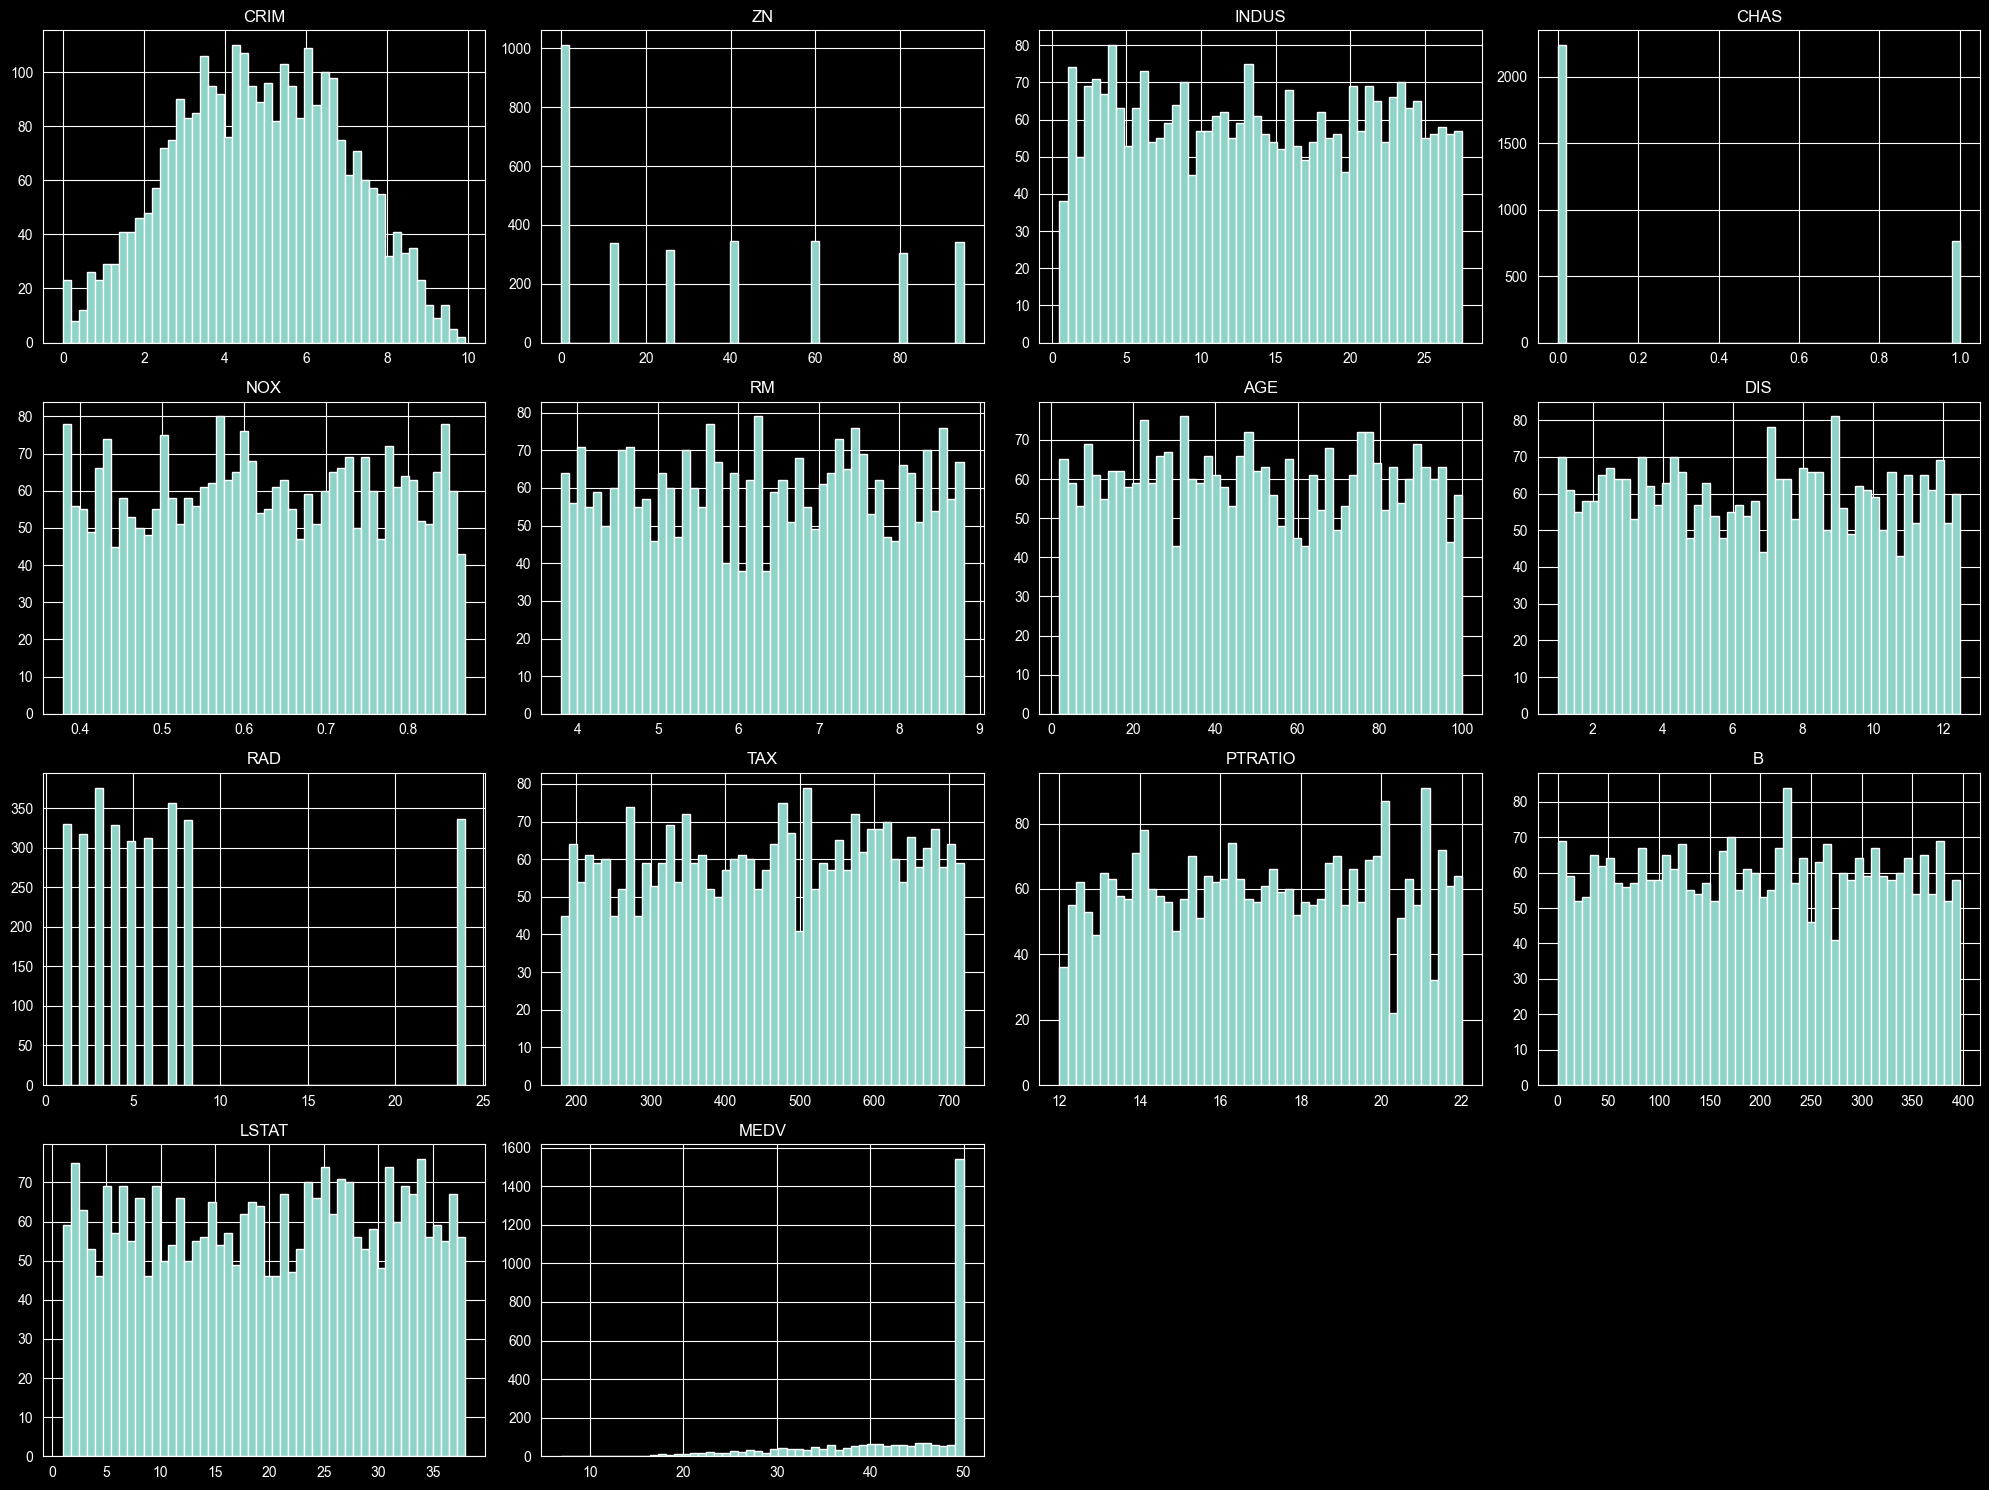

In [5]:
#matplotlib inline

import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20,15))
plt.tight_layout()
plt.show()

In [6]:
# Train Test Splitting

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing, housing['CHAS']):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]



In [7]:
    strat_test_set['CHAS'].value_counts()

CHAS
0    448
1    152
Name: count, dtype: int64

In [8]:
    strat_train_set['CHAS'].value_counts()

CHAS
0    1791
1     609
Name: count, dtype: int64

In [9]:
448/152

2.9473684210526314

In [10]:
1791/609

2.9408866995073892

array([[<Axes: xlabel='RM', ylabel='RM'>,
        <Axes: xlabel='MEDV', ylabel='RM'>,
        <Axes: xlabel='ZN', ylabel='RM'>,
        <Axes: xlabel='LSTAT', ylabel='RM'>],
       [<Axes: xlabel='RM', ylabel='MEDV'>,
        <Axes: xlabel='MEDV', ylabel='MEDV'>,
        <Axes: xlabel='ZN', ylabel='MEDV'>,
        <Axes: xlabel='LSTAT', ylabel='MEDV'>],
       [<Axes: xlabel='RM', ylabel='ZN'>,
        <Axes: xlabel='MEDV', ylabel='ZN'>,
        <Axes: xlabel='ZN', ylabel='ZN'>,
        <Axes: xlabel='LSTAT', ylabel='ZN'>],
       [<Axes: xlabel='RM', ylabel='LSTAT'>,
        <Axes: xlabel='MEDV', ylabel='LSTAT'>,
        <Axes: xlabel='ZN', ylabel='LSTAT'>,
        <Axes: xlabel='LSTAT', ylabel='LSTAT'>]], dtype=object)

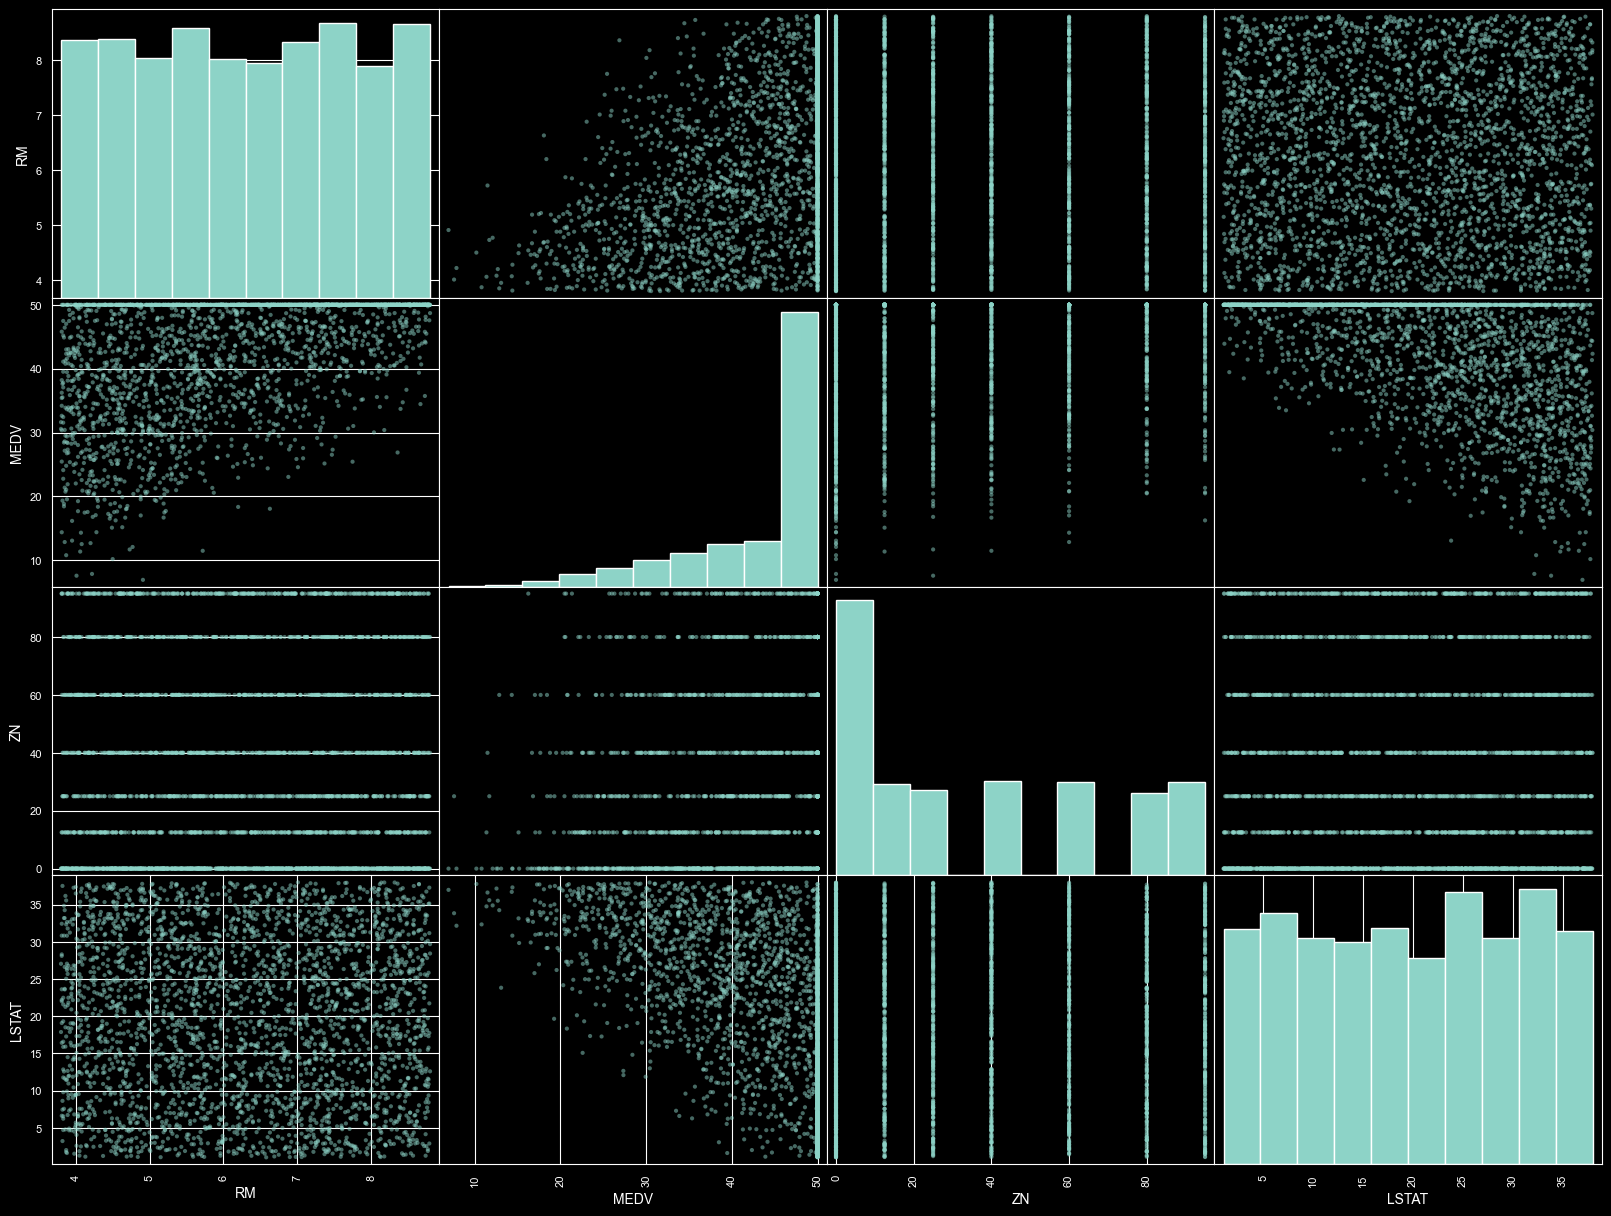

In [11]:
from pandas.plotting import scatter_matrix

attributes = ["RM","MEDV","ZN","LSTAT"]
scatter_matrix(housing[attributes], figsize=(20,15))

<Axes: xlabel='RM', ylabel='MEDV'>

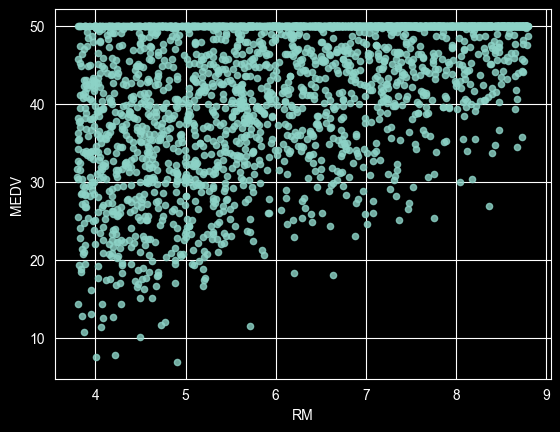

In [12]:
housing.plot(kind="scatter", x="RM", y="MEDV", alpha=0.8)

In [13]:
## Trying Out Attribute Combination

housing["TAXRM"] = housing["TAX"]/housing["RM"]

housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TAXRM
0,2.802,0.0,1.18,0,0.500,4.50,12.0,9.52,24,269,17.9,12.61,4.47,50.00,59.777778
1,2.548,95.0,5.87,1,0.488,6.75,81.3,1.07,3,612,15.4,61.71,36.42,39.70,90.666667
2,7.903,0.0,10.19,0,0.676,7.84,73.5,7.17,7,260,17.5,329.19,23.89,50.00,33.163265
3,4.693,0.0,1.74,0,0.759,8.73,85.8,10.96,7,464,16.5,331.06,7.02,50.00,53.150057
4,4.642,0.0,16.95,0,0.642,5.02,47.3,4.10,24,404,18.8,334.53,29.71,25.28,80.478088


In [14]:
# Looking for Correlations

corr_matrix = housing.corr()

corr_matrix['MEDV'].sort_values(ascending=False)

MEDV       1.000000
RM         0.482362
ZN         0.184479
DIS        0.090877
CHAS       0.056508
B          0.015225
INDUS     -0.014942
RAD       -0.036468
AGE       -0.070986
PTRATIO   -0.142183
NOX       -0.210636
TAX       -0.239847
CRIM      -0.368774
TAXRM     -0.495457
LSTAT     -0.560831
Name: MEDV, dtype: float64

<Axes: xlabel='TAXRM', ylabel='MEDV'>

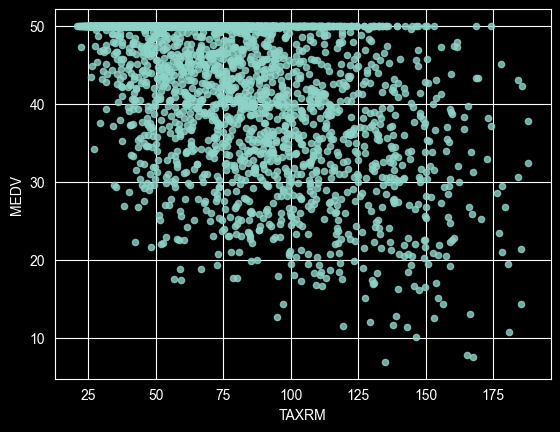

In [15]:
housing.plot(kind="scatter", x="TAXRM", y="MEDV", alpha=0.8)

In [16]:
housing = strat_train_set.drop("MEDV", axis=1)
housing_labels = strat_train_set["MEDV"].copy()

In [17]:
#Creating a Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

my_pipeline = Pipeline([
    ('std_scaler', StandardScaler())
])

In [18]:
housing_num = my_pipeline.fit_transform(housing)
housing_num

array([[-1.07921122, -1.02239648, -0.3275394 , ..., -0.17993302,
         0.61081314, -0.52373832],
       [-0.12534383,  0.14626533, -0.04361746, ...,  0.47978764,
         0.92671757, -1.54691641],
       [-1.16207243, -0.65718966,  0.65281889, ...,  0.51450978,
         1.35991762,  0.41658004],
       ...,
       [-1.48484573, -0.29198285, -0.71586314, ..., -0.80493154,
         0.4214645 , -1.09258437],
       [-0.00635129, -1.02239648, -1.62364945, ..., -1.42993006,
        -1.67407019,  0.89791132],
       [ 1.23993908, -0.29198285, -0.42684842, ..., -0.28409944,
        -1.07436328, -1.04975799]], shape=(2400, 13))

In [19]:
# Selecting models
# Linear Regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(housing_num, housing_labels)


LinearRegression()

In [20]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]

prepared_data = my_pipeline.transform(some_data)

model.predict(prepared_data)

list(some_labels)

[50.0, 38.49, 40.2, 50.0, 43.15]

In [21]:
# Evaluating the model
from sklearn.metrics import mean_squared_error

housing_predictions = model.predict(housing_num)

mse = mean_squared_error(housing_labels, housing_predictions)
rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions))

print(mse)
print(rmse)

20.133331539206115
4.487018112199472


In [22]:
# Using better evaluation technique - Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, housing_num, housing_labels, scoring='neg_mean_squared_error', cv=10)
rmse_scores = np.sqrt(-scores)

print(rmse_scores)

[4.53239819 4.0277891  4.62325074 4.52301857 4.65480489 4.70103597
 4.31555131 4.65141215 4.70057956 4.33771339]


In [25]:
def print_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard Deviation:", scores.std())

In [24]:
print_scores(rmse_scores)

Scores: [4.53239819 4.0277891  4.62325074 4.52301857 4.65480489 4.70103597
 4.31555131 4.65141215 4.70057956 4.33771339]
Mean: 4.506755387198981
Standard Deviation: 0.2066865019254016


In [26]:
# DecisionTree
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(housing_num, housing_labels)

# Using better evaluation technique - Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, housing_num, housing_labels, scoring='neg_mean_squared_error', cv=10)
rmse_scores = np.sqrt(-scores)

print(rmse_scores)

[5.61920071 5.12301807 5.59847241 5.53398225 5.38173775 4.84497605
 5.14366131 5.79155768 5.81489886 4.9455726 ]


In [27]:
print_scores(rmse_scores)

Scores: [5.61920071 5.12301807 5.59847241 5.53398225 5.38173775 4.84497605
 5.14366131 5.79155768 5.81489886 4.9455726 ]
Mean: 5.379707770673202
Standard Deviation: 0.32924916171753366


In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(housing_num, housing_labels)

# Using better evaluation technique - Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, housing_num, housing_labels, scoring='neg_mean_squared_error', cv=10)
rmse_scores = np.sqrt(-scores)

print(rmse_scores)

[3.27747875 3.11379321 3.71220929 3.0800648  3.32523278 3.06436295
 3.23562887 3.66270613 3.34674275 3.00674459]


In [29]:
print_scores(rmse_scores)

Scores: [3.25937642 3.13555364 3.65249085 3.1113777  3.36236988 3.07657827
 3.29182294 3.60682374 3.33008927 2.9684121 ]
Mean: 3.2794894800086984
Standard Deviation: 0.2105196146339043


Testing the Model on test data

In [33]:
X_test = strat_test_set.drop("MEDV", axis=1)
y_test = strat_test_set["MEDV"].copy()
X_test_prepared = my_pipeline.transform(X_test)
final_predictions = model.predict(X_test_prepared)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))

print(final_predictions, list(y_test))

[49.414  49.618  47.7338 37.8999 42.0706 46.1178 49.8538 49.9506 27.9126
 28.0745 44.3974 49.6976 46.2598 48.5605 47.4696 49.8546 49.7436 48.4042
 50.     46.5367 42.153  49.164  49.4321 49.9984 43.0516 48.0669 39.2785
 23.5699 50.     49.8754 40.3478 50.     49.8091 46.2366 45.4231 31.6396
 49.7803 49.7993 28.5    22.3984 41.769  46.6982 47.9165 49.398  49.6764
 41.6807 46.8811 39.8411 42.0142 46.7046 44.0526 49.7598 40.5805 48.1654
 49.3949 50.     49.3835 40.4907 36.0221 40.0326 40.3641 37.6096 49.9658
 50.     46.2404 44.5713 49.5073 36.9049 30.2974 33.0715 37.4193 39.1697
 49.562  49.9996 47.6329 46.3927 45.0968 49.8959 41.007  49.4318 39.9736
 49.379  49.9984 45.6364 50.     44.6287 34.8969 26.3415 49.6725 49.6953
 29.9064 42.8476 40.4213 50.     24.5103 28.4884 41.3809 36.375  37.8256
 49.2806 42.5231 34.0609 49.8017 38.8585 45.2092 48.7783 32.0986 48.7301
 24.3262 50.     48.2683 50.     42.8893 39.6697 35.3963 49.4718 20.8763
 49.9046 28.4377 34.3808 29.8449 36.3214 36.4999 41